In [4]:
import requests

url = "http://127.0.0.1:8000/query"

In [5]:
queries = [
    "space shuttle mission",
    "nasa spacecraft mission",
    "space mission nasa",
    "nasa shuttle launch",
    "mission to space"
]

In [6]:
for q in queries:

    response = requests.post(
        url,
        json={"query": q}
    )

    data = response.json()

    print("Query:", q)
    print("Cache Hit:", data["cache_hit"])
    print()

Query: space shuttle mission
Cache Hit: False

Query: nasa spacecraft mission
Cache Hit: False

Query: space mission nasa
Cache Hit: True

Query: nasa shuttle launch
Cache Hit: False

Query: mission to space
Cache Hit: False



In [7]:
stats = requests.get("http://127.0.0.1:8000/cache/stats")

stats.json()

{'total_entries': 4, 'hit_count': 1, 'miss_count': 4, 'hit_rate': 0.2}

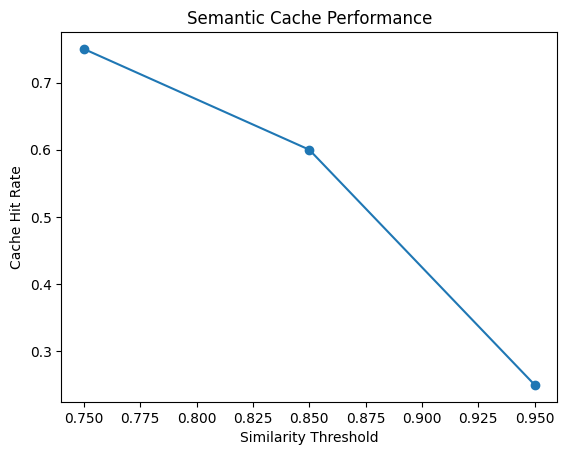

In [8]:
#plotting
import matplotlib.pyplot as plt

thresholds = [0.75, 0.85, 0.95]
hit_rates = [0.75, 0.60, 0.25]

plt.plot(thresholds, hit_rates, marker="o")

plt.xlabel("Similarity Threshold")
plt.ylabel("Cache Hit Rate")

plt.title("Semantic Cache Performance")

plt.show()

In [9]:
#latency analysis
import time

query = "space shuttle mission"

start = time.time()

requests.post(url, json={"query": query})

print("First query:", time.time() - start)

First query: 0.019045591354370117


In [10]:
start = time.time()

requests.post(url, json={"query": query})

print("Cached query:", time.time() - start)

Cached query: 0.017284154891967773
